In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import(
    KMeans,AgglomerativeClustering,
    DBSCAN
)
from scipy.cluster.hierarchy import     (
    linkage,dendrogram
)

In [3]:
X,y=make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
    
)

In [5]:
print("Feature Shape: ",X.shape)
print("Target Shape: ",y.shape)

Feature Shape:  (300, 2)
Target Shape:  (300,)


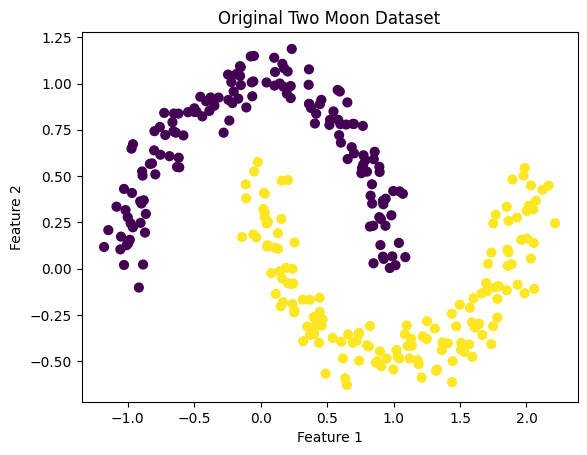

In [6]:
plt.Figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='viridis',
    s=40,

)

plt.title("Original Two Moon Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.savefig(
    'images/original_dataset.png'
)

plt.show()

In [7]:
kmeans=KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_label=kmeans.fit_predict(X)

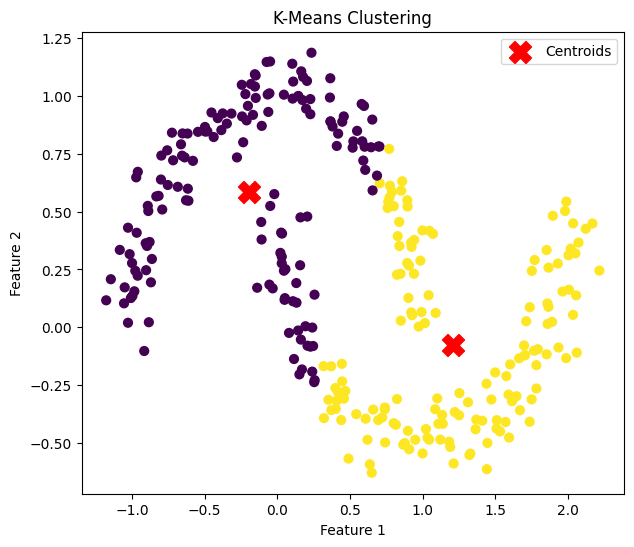

In [9]:
plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=kmeans_label,
    cmap="viridis",
    s=40
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.savefig(
    "images/kmeans_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
agg=AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)
agg_labels=agg.fit_predict(X)

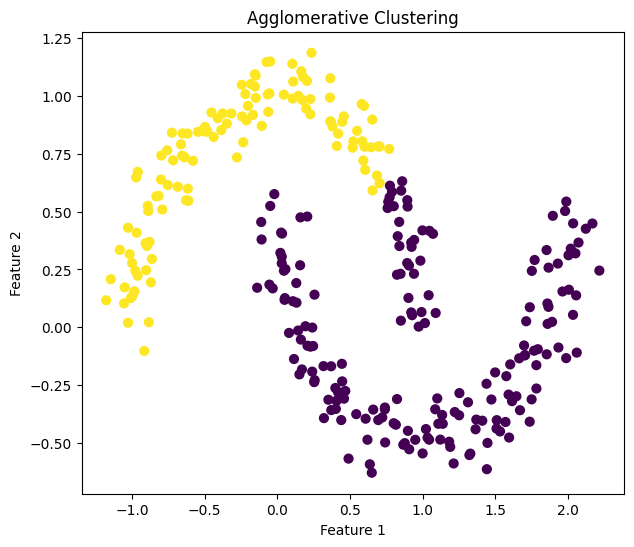

In [11]:
plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=agg_labels,
    cmap="viridis",
    s=40
)

plt.title("Agglomerative Clustering")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.savefig(
    "images/agglomerative_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

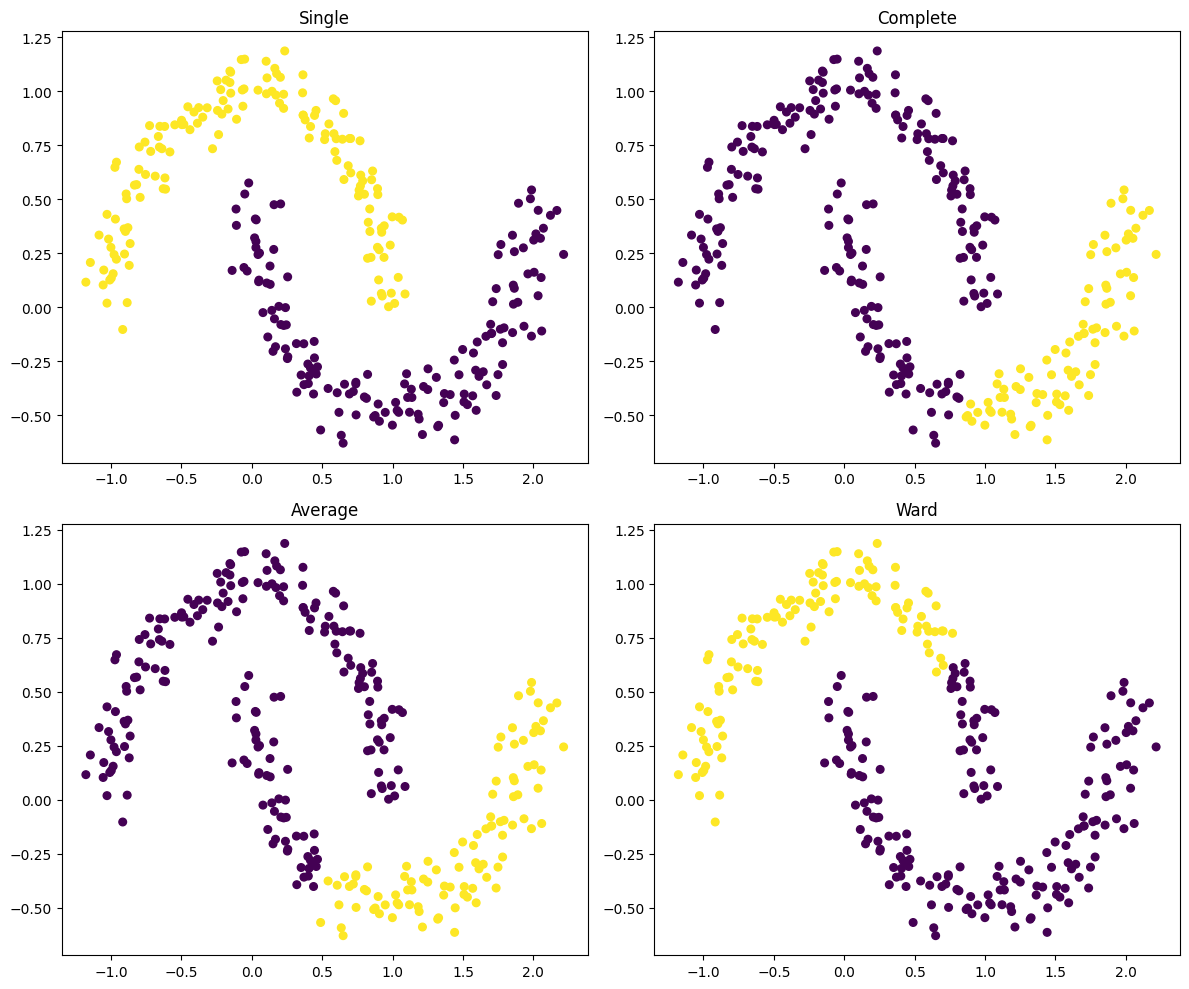

In [12]:
linkages = [
    "single",
    "complete",
    "average",
    "ward"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

for ax, linkage_name in zip(axes.ravel(), linkages):

    model = AgglomerativeClustering(
        n_clusters=2,
        linkage=linkage_name
    )

    labels = model.fit_predict(X)

    ax.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="viridis",
        s=30
    )

    ax.set_title(
        linkage_name.title()
    )

plt.tight_layout()

plt.savefig(
    "images/linkage_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

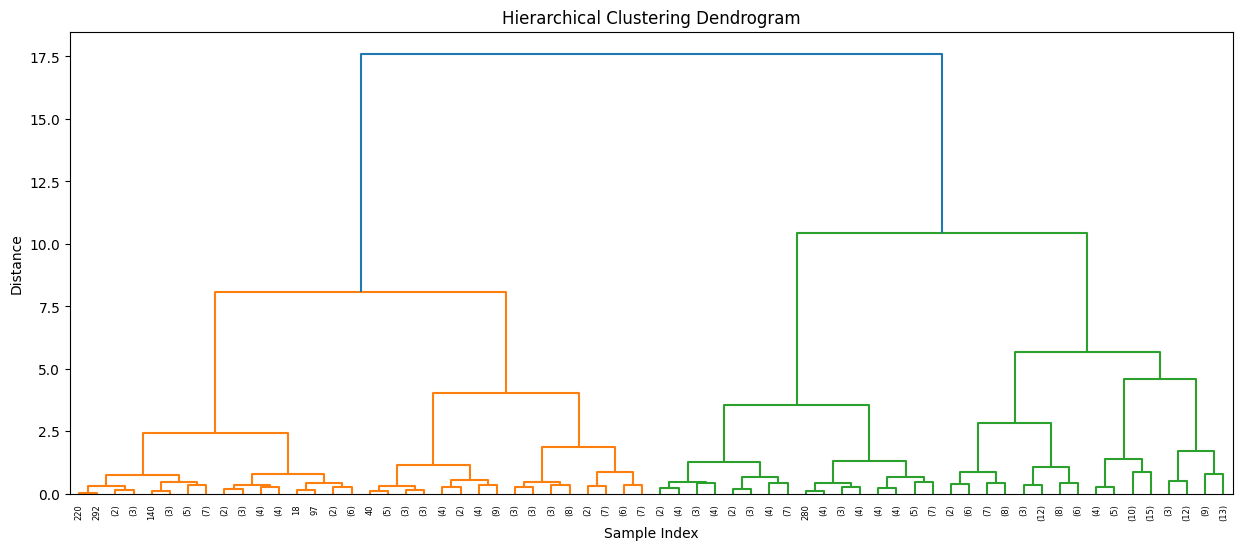

In [13]:
linkage_matrix = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(15,6))

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Sample Index")
plt.ylabel("Distance")

plt.savefig(
    "images/dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X)

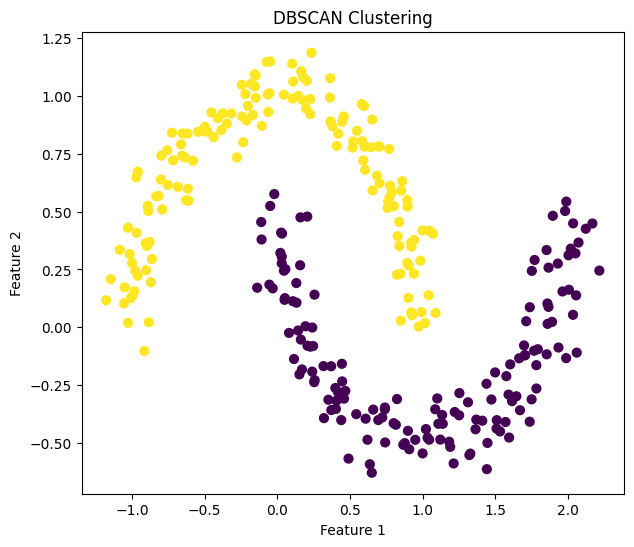

In [16]:
plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=dbscan_labels,
    cmap="viridis",
    s=40
)

plt.title("DBSCAN Clustering")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.savefig(
    "images/dbscan_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

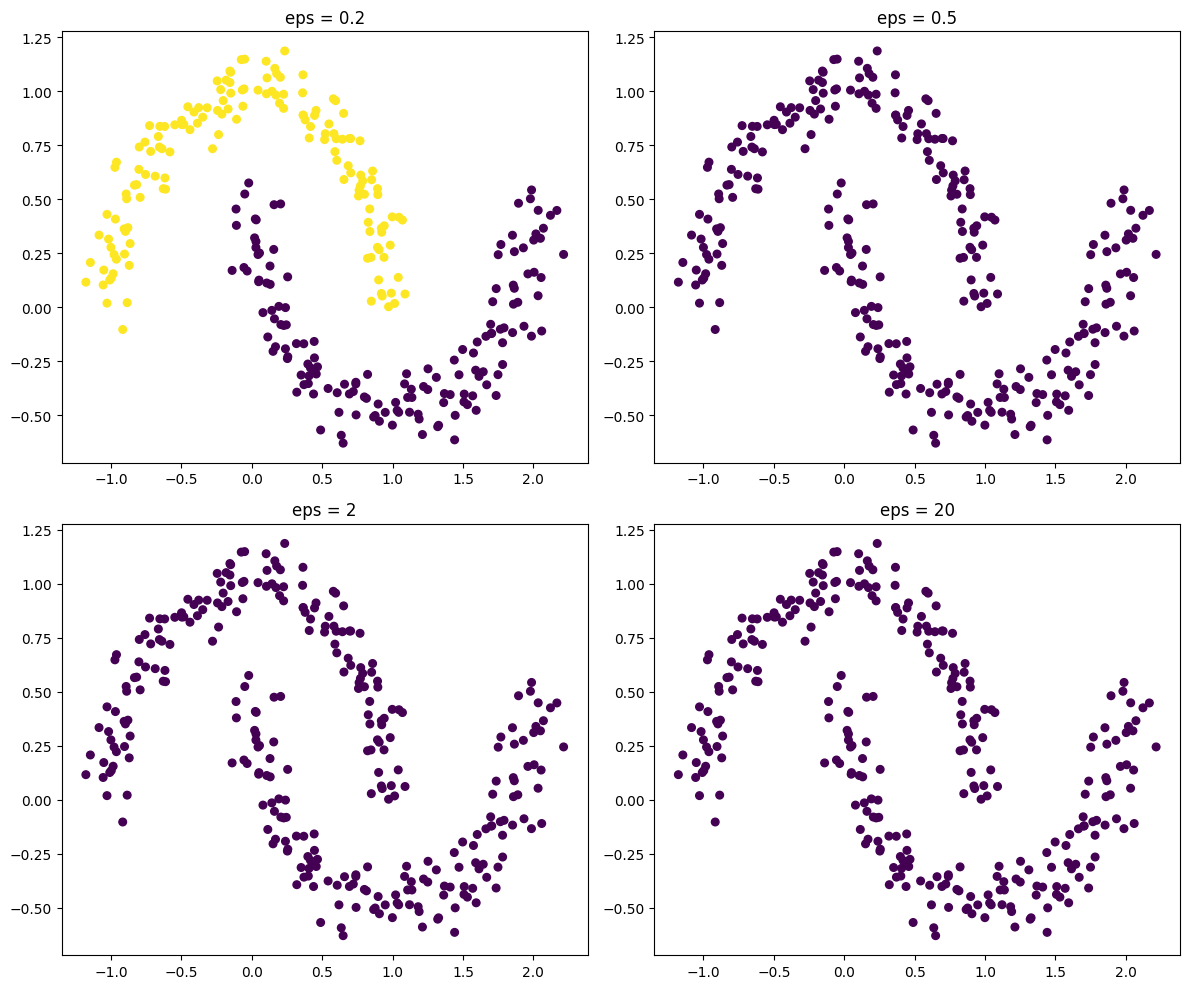

In [18]:
eps_values = [
    0.2,
    0.5,
    2,
    20
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

for ax, eps in zip(axes.ravel(), eps_values):

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X)

    ax.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="viridis",
        s=30
    )

    ax.set_title(
        f"eps = {eps}"
    )

plt.tight_layout()

plt.savefig(
    "images/eps_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

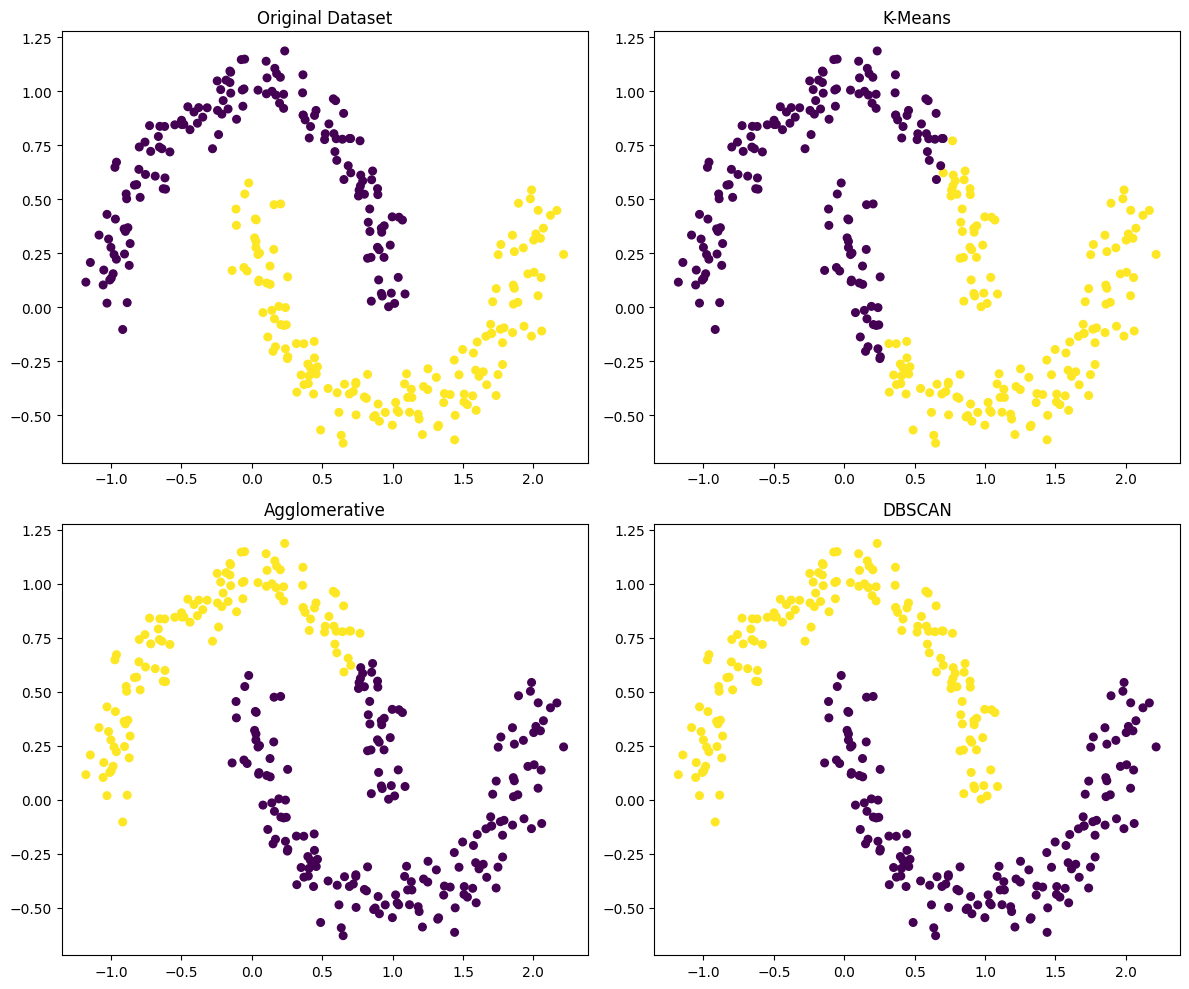

In [20]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

plots = [
    ("Original Dataset", y),
    ("K-Means", kmeans_label),
    ("Agglomerative", agg_labels),
    ("DBSCAN", dbscan_labels)
]

for ax, (title, labels) in zip(axes.ravel(), plots):

    ax.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="viridis",
        s=30
    )

    ax.set_title(title)

plt.tight_layout()

plt.savefig(
    "images/comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()